# Restricciones monotónicas: ejemplo simple

Esta notebook muestra qué significa imponer una relación monotónica entre una variable explicativa y la predicción de un modelo, usando un ejemplo sintético con `age` y una `target` binaria.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

## Monotonicidad creciente

En este ejemplo, la función `f(x) = x ** 2` es monotónica creciente para valores de `x >= 0`: si `x` aumenta, `f(x)` también aumenta o se mantiene igual.

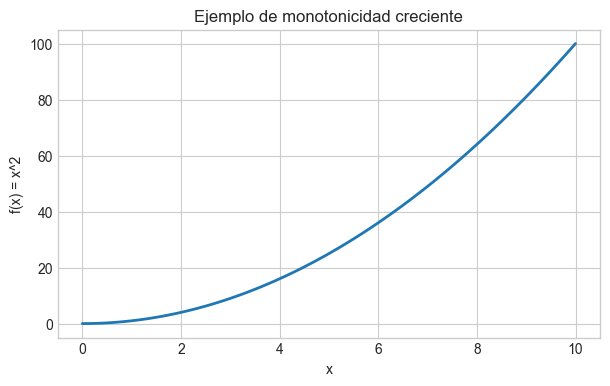

In [2]:
x = np.linspace(0, 10, 100)
y_creciente = x**2

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y_creciente, linewidth=2)
ax.set(title="Ejemplo de monotonicidad creciente", xlabel="x", ylabel="f(x) = x^2")
plt.show()

## Monotonicidad decreciente

En este ejemplo, la función `f(x) = exp(-x)` es monotónica decreciente: si `x` aumenta, `f(x)` disminuye.

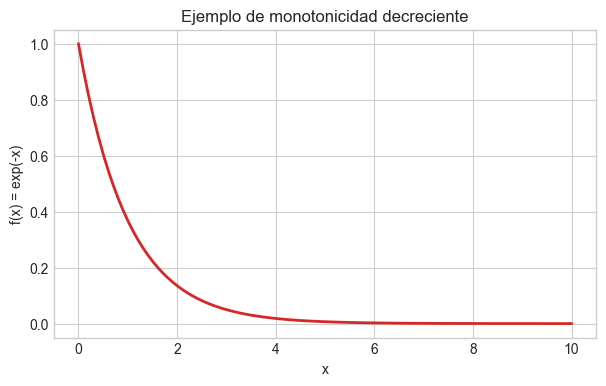

In [3]:
x = np.linspace(0, 10, 100)
y_decreciente = np.exp(-x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y_decreciente, color="tab:red", linewidth=2)
ax.set(title="Ejemplo de monotonicidad decreciente", xlabel="x", ylabel="f(x) = exp(-x)")
plt.show()

## Dataset sintético

Simulamos 1000 observaciones con una variable `age` y un `target` binario. La probabilidad promedio de `target = 1` tiende a caer con la edad, pero agregamos ruido individual y una pequeña ondulación local para que la relación observada no sea perfectamente monotónica.

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
n = 1_000

age = rng.integers(18, 86, size=n)
individual_noise = rng.normal(0, 0.75, size=n)
local_wiggle = 0.45 * np.sin((age - 18) / 6)

logit = 2.3 - 0.055 * age + local_wiggle + individual_noise
prob_target = 1 / (1 + np.exp(-logit))
target = rng.binomial(1, prob_target)

df = pd.DataFrame({"age": age, "target": target, "prob_target": prob_target})
df.head()

,age,target,prob_target
0,24,1,0.919352
1,70,1,0.236501
2,62,1,0.429463
3,47,1,0.315550
4,47,0,0.297440


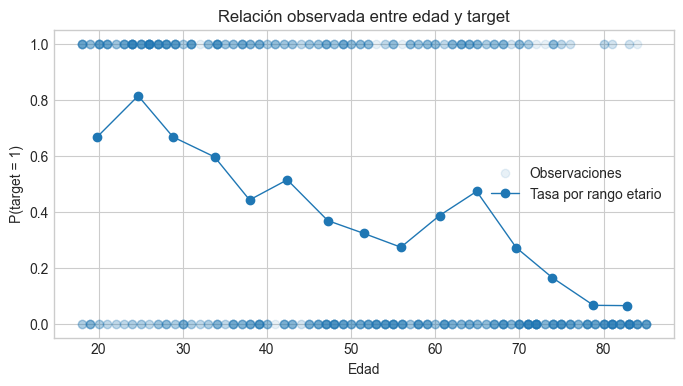

,age_bin,mean_age,target_rate,n
0,"[18.0, 22.467)",19.809524,0.666667,63
1,"[22.467, 26.933)",24.680000,0.813333,75
2,"[26.933, 31.4)",28.814815,0.666667,81
3,"[31.4, 35.867)",33.761905,0.595238,42
4,"[35.867, 40.333)",37.922078,0.441558,77
5,"[40.333, 44.8)",42.405405,0.513514,37
6,"[44.8, 49.267)",47.218391,0.367816,87
7,"[49.267, 53.733)",51.508475,0.322034,59
8,"[53.733, 58.2)",55.909091,0.272727,77
9,"[58.2, 62.667)",60.508772,0.385965,57


In [35]:
age_profile = (
    df.assign(age_bin=pd.cut(df["age"], bins=15, right=False))
    .groupby("age_bin", observed=True)
    .agg(
        mean_age=("age", "mean"), 
        target_rate=("target", "mean"),
        n=("target", "size")
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df["age"], df["target"], alpha=0.1, label="Observaciones")
ax.plot(age_profile["mean_age"], age_profile["target_rate"], marker="o", linewidth=1, label="Tasa por rango etario")
ax.set(title="Relación observada entre edad y target", xlabel="Edad", ylabel="P(target = 1)")
ax.legend()
plt.show()

age_profile

In [6]:
X = df[["age"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

## Función auxiliar para graficar árboles de HistGradientBoosting

`HistGradientBoostingClassifier` permite restricciones monotónicas. Sus árboles quedan guardados internamente como `TreePredictor`, por eso usamos una función auxiliar para visualizarlos.

Importante: el valor interno de cada hoja no es una probabilidad. Es una contribución al score del modelo, en escala de log-odds. Para que el gráfico sea más interpretable, además mostramos la probabilidad promedio predicha por el modelo final para las observaciones de entrenamiento que caen en cada hoja.

In [23]:
def _leaf_ids_for_tree(tree, X_values):
    """Return the leaf id reached by each row in X_values for a TreePredictor."""
    nodes = tree.nodes
    leaf_ids = []

    for row in X_values:
        node_id = 0
        while not nodes[node_id]["is_leaf"]:
            node = nodes[node_id]
            feature_idx = int(node["feature_idx"])
            threshold = node["num_threshold"]
            if row[feature_idx] <= threshold:
                node_id = int(node["left"])
            else:
                node_id = int(node["right"])
        leaf_ids.append(node_id)

    return np.array(leaf_ids)


def plot_hist_gradient_boosting_tree(model, iteration, feature_names=None, X_reference=None, ax=None):
    """Plot one internal tree from a fitted HistGradientBoostingClassifier."""
    if feature_names is None:
        feature_names = [f"x{i}" for i in range(model.n_features_in_)]

    tree = model._predictors[iteration][0]
    nodes = tree.nodes
    positions = {}
    labels = {}
    leaf_probabilities = {}

    if X_reference is not None:
        if hasattr(X_reference, "loc"):
            X_values = X_reference.loc[:, feature_names].to_numpy()
        else:
            X_values = np.asarray(X_reference)

        leaf_ids = _leaf_ids_for_tree(tree, X_values)
        predicted_probabilities = model.predict_proba(X_reference)[:, 1]

        for leaf_id in np.unique(leaf_ids):
            in_leaf = leaf_ids == leaf_id
            leaf_probabilities[int(leaf_id)] = {
                "mean_probability": predicted_probabilities[in_leaf].mean(),
                "n": in_leaf.sum(),
            }

    def walk(node_id, depth=0, x_pos=0):
        node = nodes[node_id]
        if node["is_leaf"]:
            positions[node_id] = (x_pos, -depth)
            # label = f"leaf\nlog-odds += {node['value']:.3f}"
            label = ""
            if node_id in leaf_probabilities:
                mean_probability = leaf_probabilities[node_id]["mean_probability"]
                n = leaf_probabilities[node_id]["n"]
                label += f"P media = {mean_probability:.2f}\nn = {n}"
            labels[node_id] = label
            return x_pos + 1

        left = int(node["left"])
        right = int(node["right"])
        next_x = walk(left, depth + 1, x_pos)
        next_x = walk(right, depth + 1, next_x)
        left_x = positions[left][0]
        right_x = positions[right][0]
        positions[node_id] = ((left_x + right_x) / 2, -depth)
        feature = feature_names[int(node["feature_idx"])]
        labels[node_id] = f"{feature} <= {node['num_threshold']:.1f}"
        return next_x

    walk(0)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))

    for node_id, node in enumerate(nodes):
        if node["is_leaf"]:
            continue
        x0, y0 = positions[node_id]
        for child in (int(node["left"]), int(node["right"])):
            x1, y1 = positions[child]
            ax.plot([x0, x1], [y0, y1], color="0.45", linewidth=1)

    for node_id, (x_pos, y_pos) in positions.items():
        ax.text(
            x_pos,
            y_pos,
            labels[node_id],
            ha="center",
            va="center",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.35"},
        )

    ax.set_title(f"Iteración {iteration + 1}")
    ax.axis("off")
    return ax

## Modelo scikit-learn sin restricción

Entrenamos un modelo flexible con `max_iter=2` y `max_depth=3`. En el enunciado aparece `n_iter=2`; en `HistGradientBoostingClassifier` el parámetro equivalente es `max_iter=2`.

In [8]:
model_unconstrained = HistGradientBoostingClassifier(
    max_iter=2,
    max_depth=3,
    learning_rate=0.7,
    random_state=RANDOM_STATE,
)

model_unconstrained.fit(X_train, y_train)
print(f"Accuracy train: {model_unconstrained.score(X_train, y_train):.3f}")
print(f"Accuracy test:  {model_unconstrained.score(X_test, y_test):.3f}")

Accuracy train: 0.690
Accuracy test:  0.723


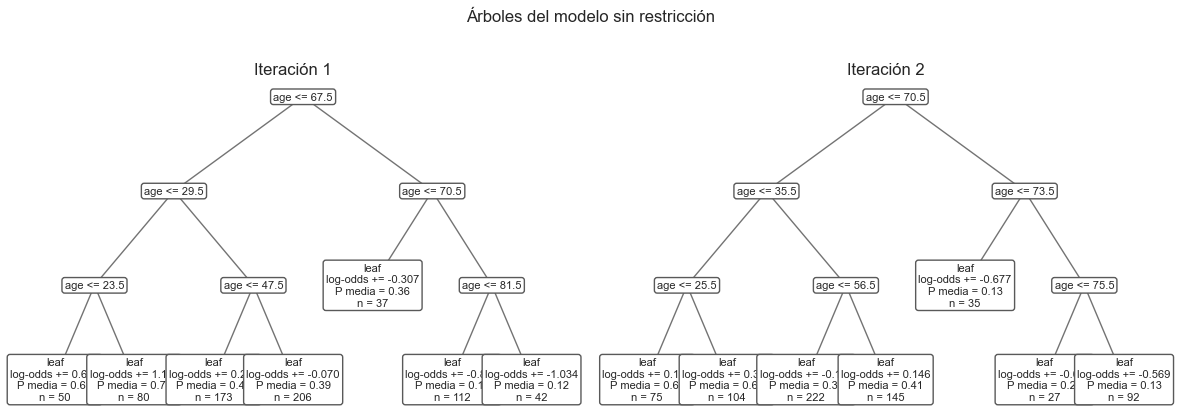

In [9]:
fig, axes = plt.subplots(1, model_unconstrained.max_iter, figsize=(12, 4))
for iteration, ax in enumerate(np.atleast_1d(axes)):
    plot_hist_gradient_boosting_tree(
        model_unconstrained,
        iteration,
        feature_names=["age"],
        X_reference=X_train,
        ax=ax,
    )
fig.suptitle("Árboles del modelo sin restricción", y=1.02)
plt.tight_layout()
plt.show()

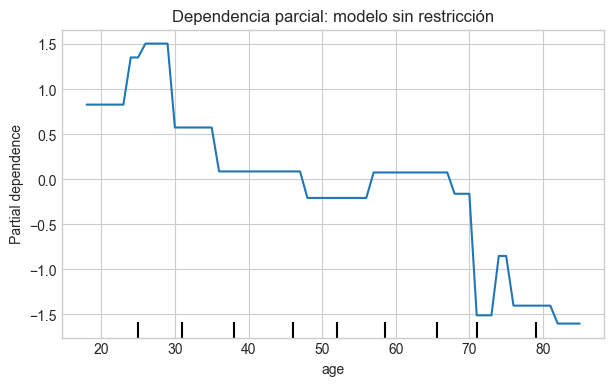

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
PartialDependenceDisplay.from_estimator(
    model_unconstrained,
    X_train,
    features=["age"],
    response_method="decision_function",
    ax=ax,
)
ax.set_title("Dependencia parcial: modelo sin restricción")
plt.show()

## Modelo scikit-learn con restricción monotónica decreciente

Ahora entrenamos el mismo tipo de modelo, pero imponiendo `monotonic_cst=[-1]`. El valor `-1` indica que la predicción debe ser monotónica decreciente respecto de `age`: a mayor edad, la probabilidad predicha de `target = 1` no debería aumentar.

In [12]:
model_constrained = HistGradientBoostingClassifier(
    max_iter=2,
    max_depth=3,
    learning_rate=0.7,
    monotonic_cst=[-1],
    random_state=RANDOM_STATE,
)

model_constrained.fit(X_train, y_train)
print(f"Accuracy train: {model_constrained.score(X_train, y_train):.3f}")
print(f"Accuracy test:  {model_constrained.score(X_test, y_test):.3f}")

Accuracy train: 0.690
Accuracy test:  0.723


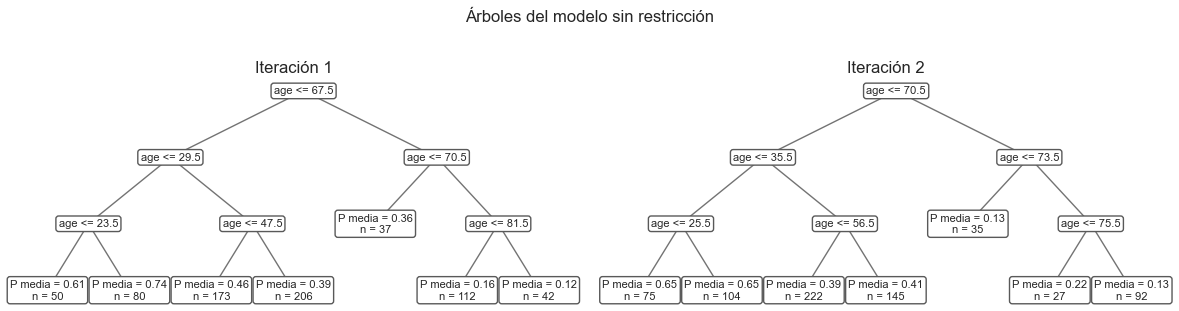

In [28]:
fig, axes = plt.subplots(1, model_unconstrained.max_iter, figsize=(12, 3))
for iteration, ax in enumerate(np.atleast_1d(axes)):
    plot_hist_gradient_boosting_tree(
        model_unconstrained,
        iteration,
        feature_names=["age"],
        X_reference=X_train,
        ax=ax,
    )
fig.suptitle("Árboles del modelo sin restricción", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
Iter 1: 
- Entre 18 y 23 años --> 0.61
- Entre 23 y 29 años --> 0.74 (acá es donde la relación se invierte) A medida que aumenta la edad se esepraría menor prob no mayor. Esta no linealidad es ruido. 
- Entre 29 y 47 años --> 0.46
- Entre 47 y 67 años --> 0.39

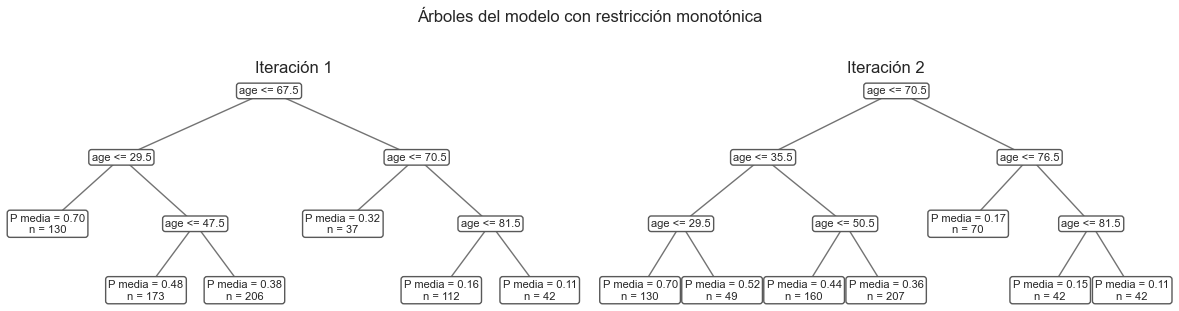

In [27]:
fig, axes = plt.subplots(1, model_constrained.max_iter, figsize=(12, 3))
for iteration, ax in enumerate(np.atleast_1d(axes)):
    plot_hist_gradient_boosting_tree(
        model_constrained,
        iteration,
        feature_names=["age"],
        X_reference=X_train,
        ax=ax,
    )
fig.suptitle("Árboles del modelo con restricción monotónica", y=1.02)
plt.tight_layout()
plt.show()

Iter 1: 
- Entre 18 y 29 años --> 0.70 (promedio)
- Entre 29 y 47 años --> 0.46
- Entre 47 y 67 años --> 0.39

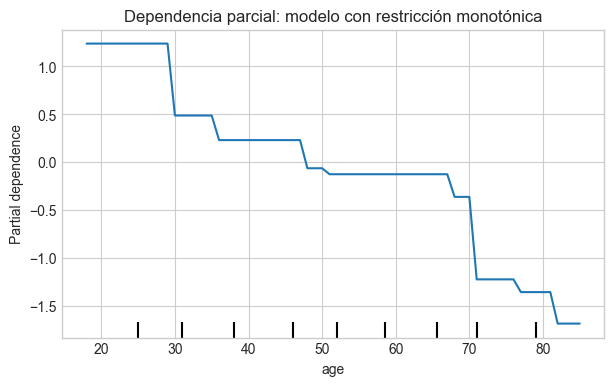

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
PartialDependenceDisplay.from_estimator(
    model_constrained,
    X_train,
    features=["age"],
    response_method="decision_function",
    ax=ax,
)
ax.set_title("Dependencia parcial: modelo con restricción monotónica")
plt.show()

## Comparación de probabilidades predichas

El gráfico siguiente compara las probabilidades predichas por ambos modelos para una grilla ordenada de edades. El modelo restringido debería mostrar una curva no creciente, mientras que el modelo sin restricción puede seguir irregularidades del dataset sintético.

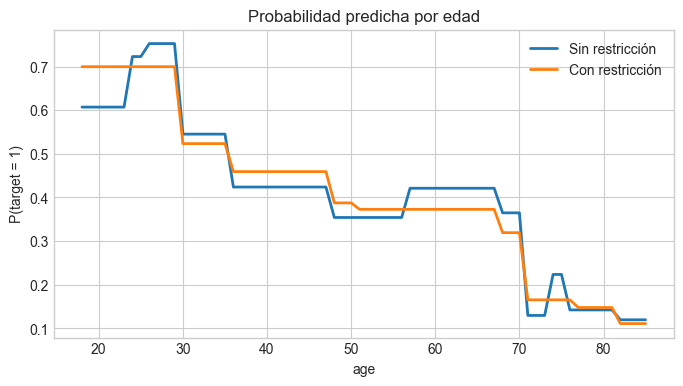

,age,sin_restriccion,con_restriccion
0,18,0.607094,0.699636
1,19,0.607094,0.699636
2,20,0.607094,0.699636
3,21,0.607094,0.699636
4,22,0.607094,0.699636


In [16]:
age_grid = pd.DataFrame({"age": np.arange(18, 86)})
predictions = age_grid.assign(
    sin_restriccion=model_unconstrained.predict_proba(age_grid)[:, 1],
    con_restriccion=model_constrained.predict_proba(age_grid)[:, 1],
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(predictions["age"], predictions["sin_restriccion"], label="Sin restricción", linewidth=2)
ax.plot(predictions["age"], predictions["con_restriccion"], label="Con restricción", linewidth=2)
ax.set(title="Probabilidad predicha por edad", xlabel="age", ylabel="P(target = 1)")
ax.legend()
plt.show()

predictions.head()

5000.0